In [1]:
import os, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
SEED = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Load & Clean

In [2]:
df = pd.read_csv('Credit_Card.csv', sep=';', on_bad_lines='skip', low_memory=False)

def _fix_dot_float(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    if ',' in s:
        s = s.replace('.', '').replace(',', '.')
        try: return float(s)
        except: return np.nan
    parts = s.split('.')
    if len(parts) > 2:
        s = parts[0] + '.' + ''.join(parts[1:])
    try: return float(s)
    except: return np.nan

df['risk_leak'] = df['risk_leak'].apply(_fix_dot_float)
# NOTE: LIMIT_BAL_LOG is recomputed in Task 2 after imputation for consistency.
# risk_leak is parsed here only to fix formatting; it is EXCLUDED from all model training.

TARGET = 'default.payment.next.month'
PAY_COLS = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Target class distribution (proportions):')
print(df[TARGET].value_counts(normalize=True).round(3).to_string())


Dataset loaded: 34,788 rows, 30 columns
Target class distribution (proportions):
default.payment.next.month
0    0.809
1    0.191


## Task 1: Exploratory Data Analysis

This section investigates the target variable distribution, descriptive statistics,
visualisations for numerical and categorical features, payment history patterns,
and feature correlations with the target.
Key focus: class imbalance, RISK_RATING, PAY_0–PAY_6, CITY, and the risk_leak leakage check.


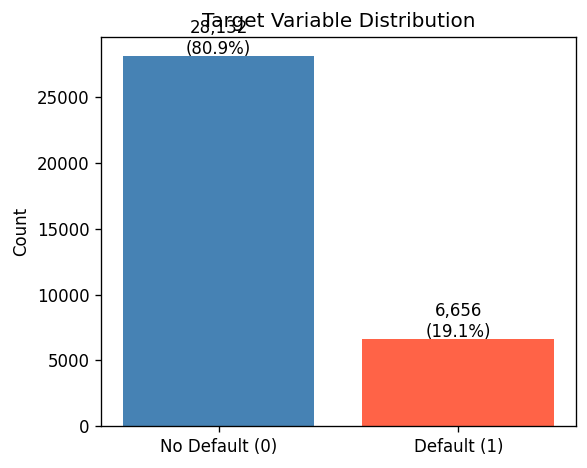

,mean,median,std,min,max
LIMIT_BAL,1.846690e+05,140000.000000,2.359319e+05,1.000000e+04,5.600000e+06
AGE,3.551830e+01,34.000000,9.236783e+00,2.100000e+01,7.900000e+01
BILL_AMT_SUM,2.948152e+05,129037.000000,5.718073e+05,-3.362590e+05,2.129266e+07
risk_leak,-5.694061e+07,0.030655,5.113956e+09,-5.350000e+11,4.120000e+11


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts()
ax.bar(['No Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/01_target_distribution.png'); plt.show()

num_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'risk_leak']
desc = df[num_features].describe().T[['mean', '50%', 'std', 'min', 'max']]
desc.columns = ['mean', 'median', 'std', 'min', 'max']
desc.to_csv('outputs/descriptive_stats.csv')
desc

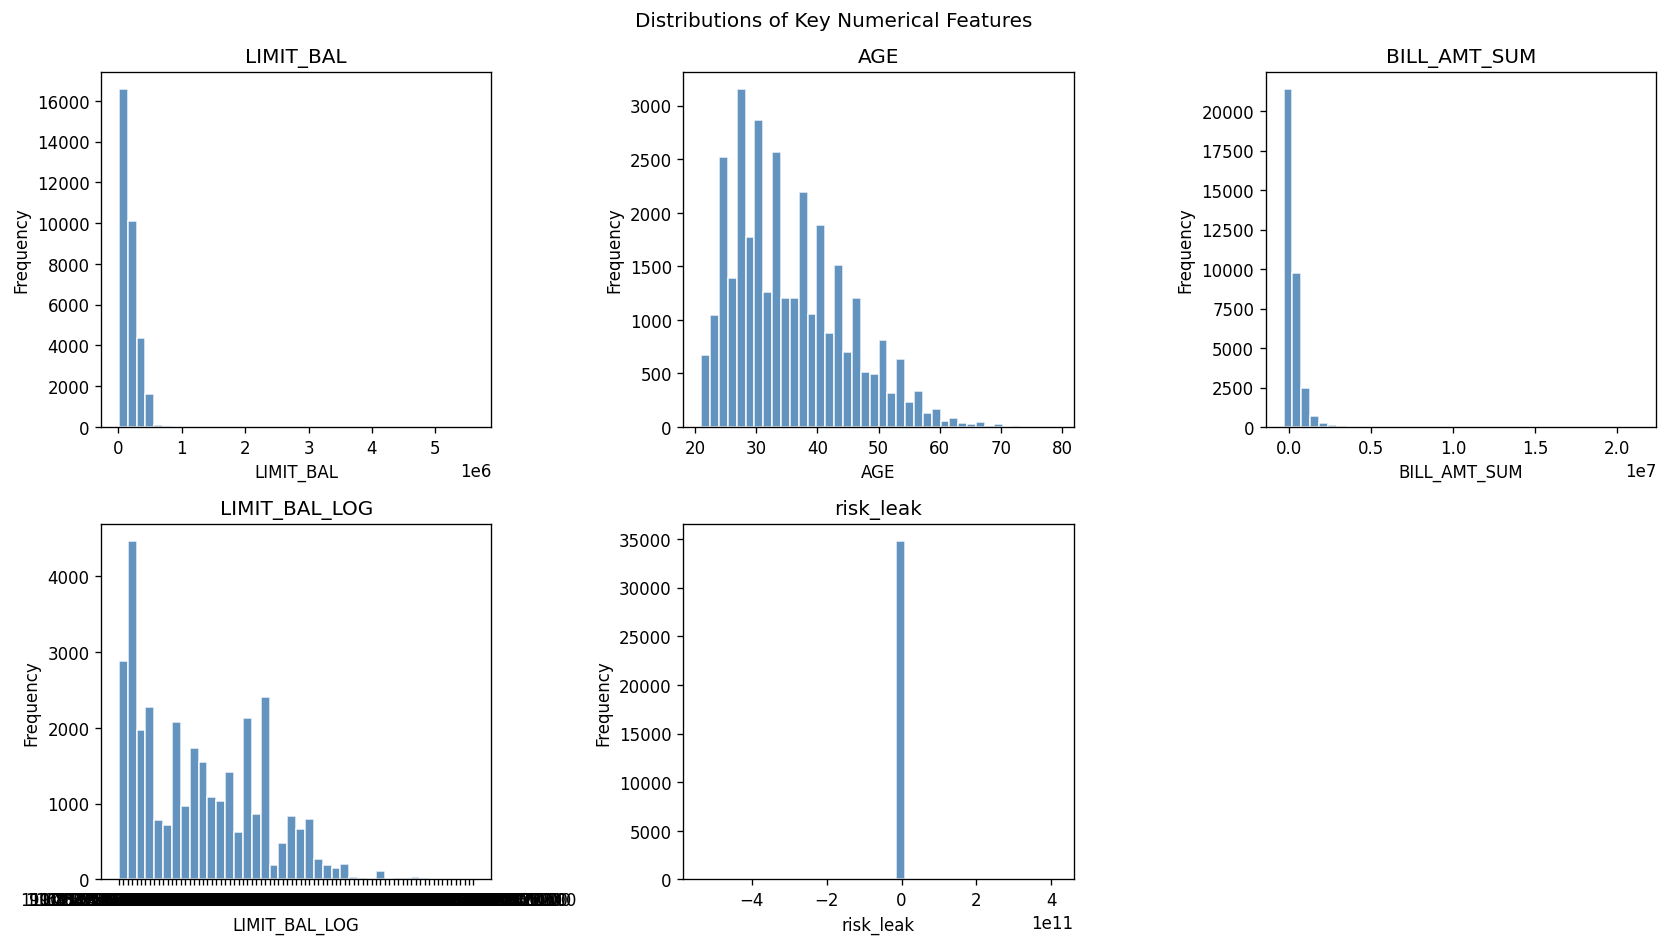

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(num_features):
    ax = axes[i // 3][i % 3]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('Frequency')
axes[1][2].axis('off')
plt.suptitle('Distributions of Key Numerical Features', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/02_numeric_histograms.png'); plt.show()

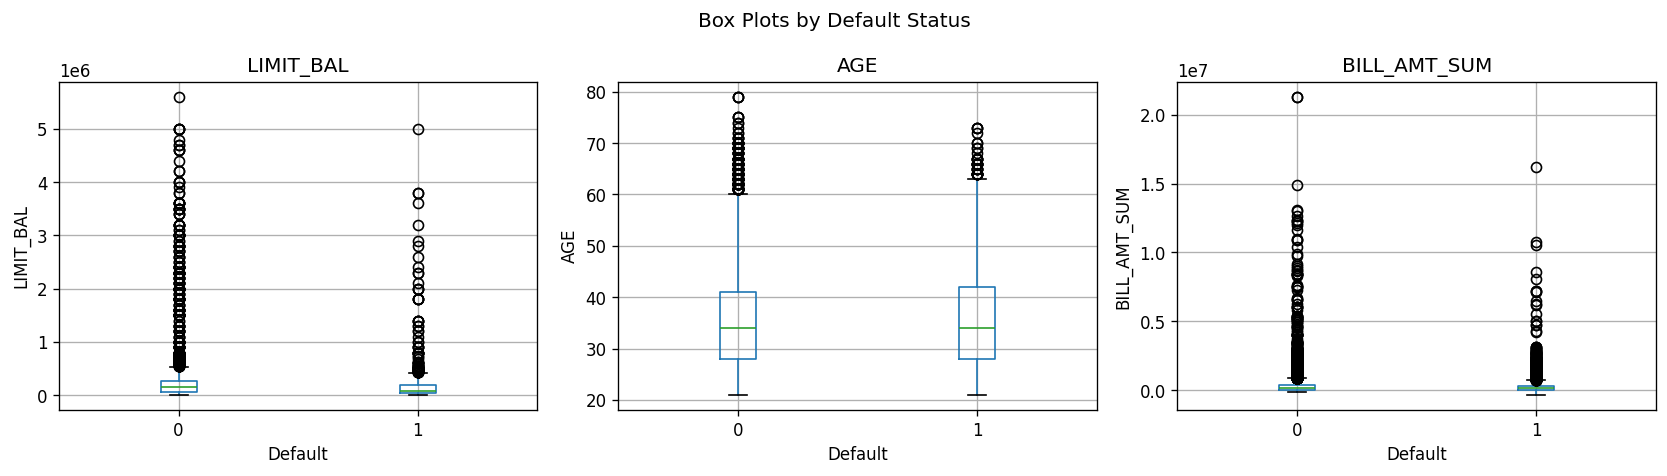

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM']):
    df.boxplot(column=col, by=TARGET, ax=ax)
    ax.set_title(col); ax.set_xlabel('Default'); ax.set_ylabel(col)
plt.suptitle('Box Plots by Default Status'); plt.tight_layout()
plt.savefig('outputs/03_boxplots_by_target.png'); plt.show()

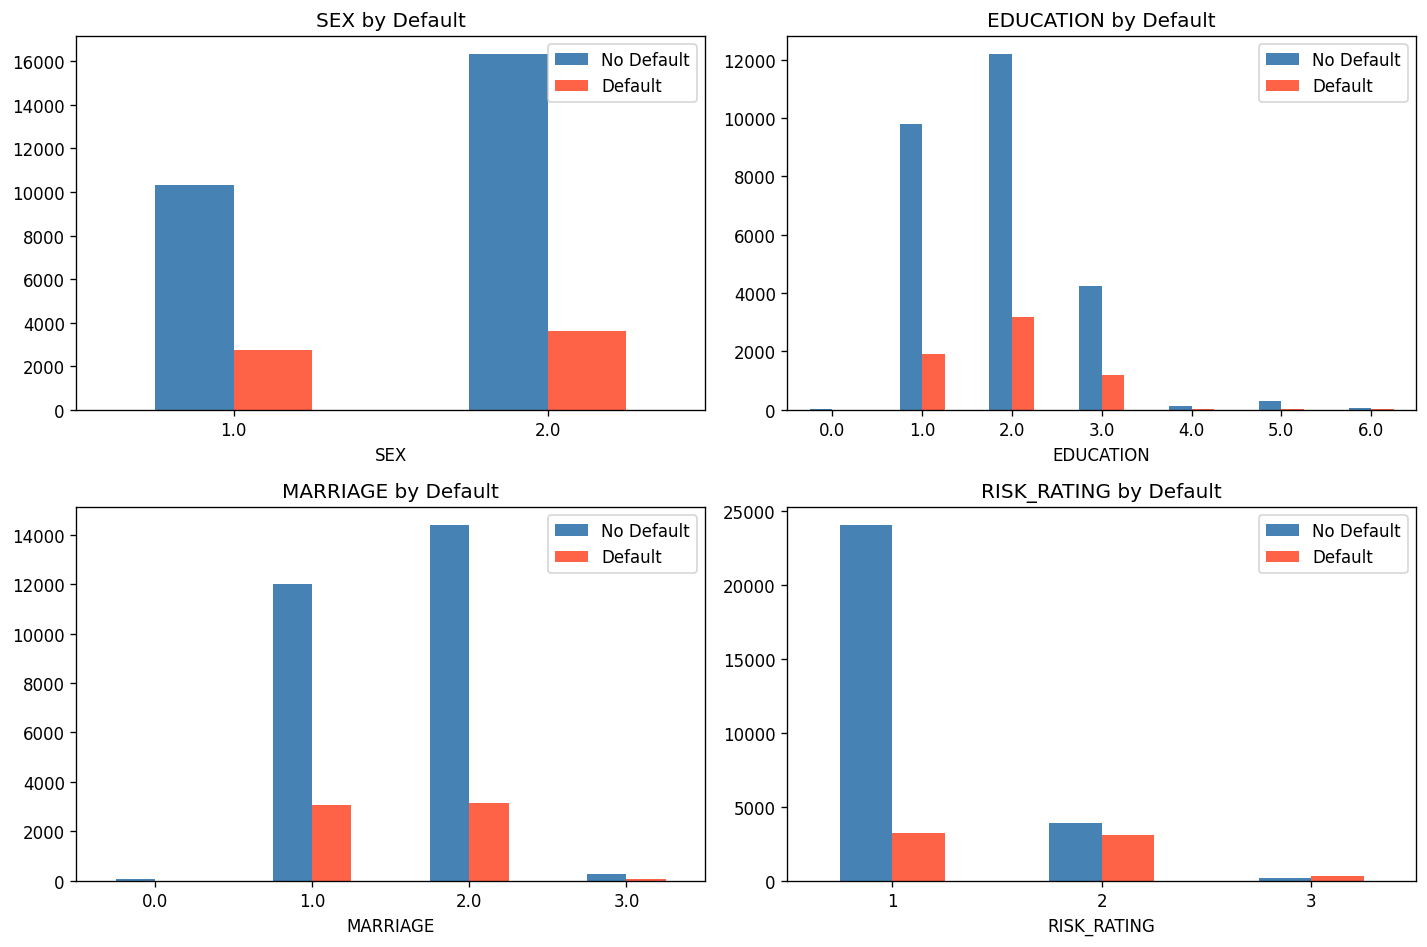

In [6]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'RISK_RATING']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    data = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    data.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'{col} by Default'); ax.set_xlabel(col); ax.legend(['No Default', 'Default'])
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('outputs/04_categorical_distributions.png'); plt.show()

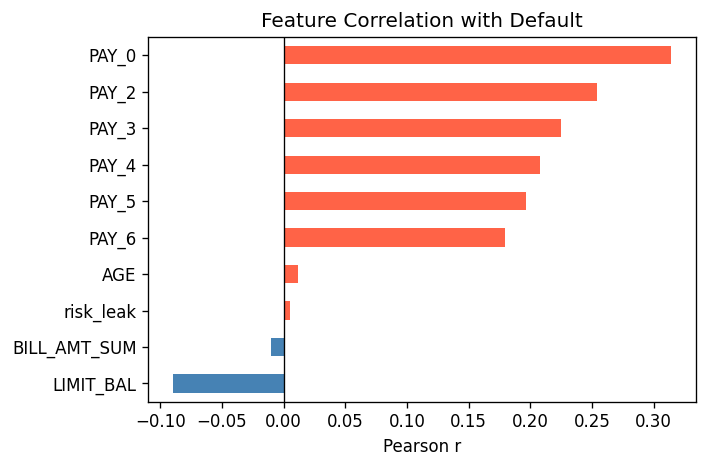

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
pay_corrs = df[PAY_COLS + ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM', 'risk_leak']].corrwith(df[TARGET]).sort_values()
pay_corrs.plot(kind='barh', ax=ax, color=['tomato' if v > 0 else 'steelblue' for v in pay_corrs.values])
ax.set_title('Feature Correlation with Default'); ax.set_xlabel('Pearson r')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('outputs/05_feature_correlations.png'); plt.show()

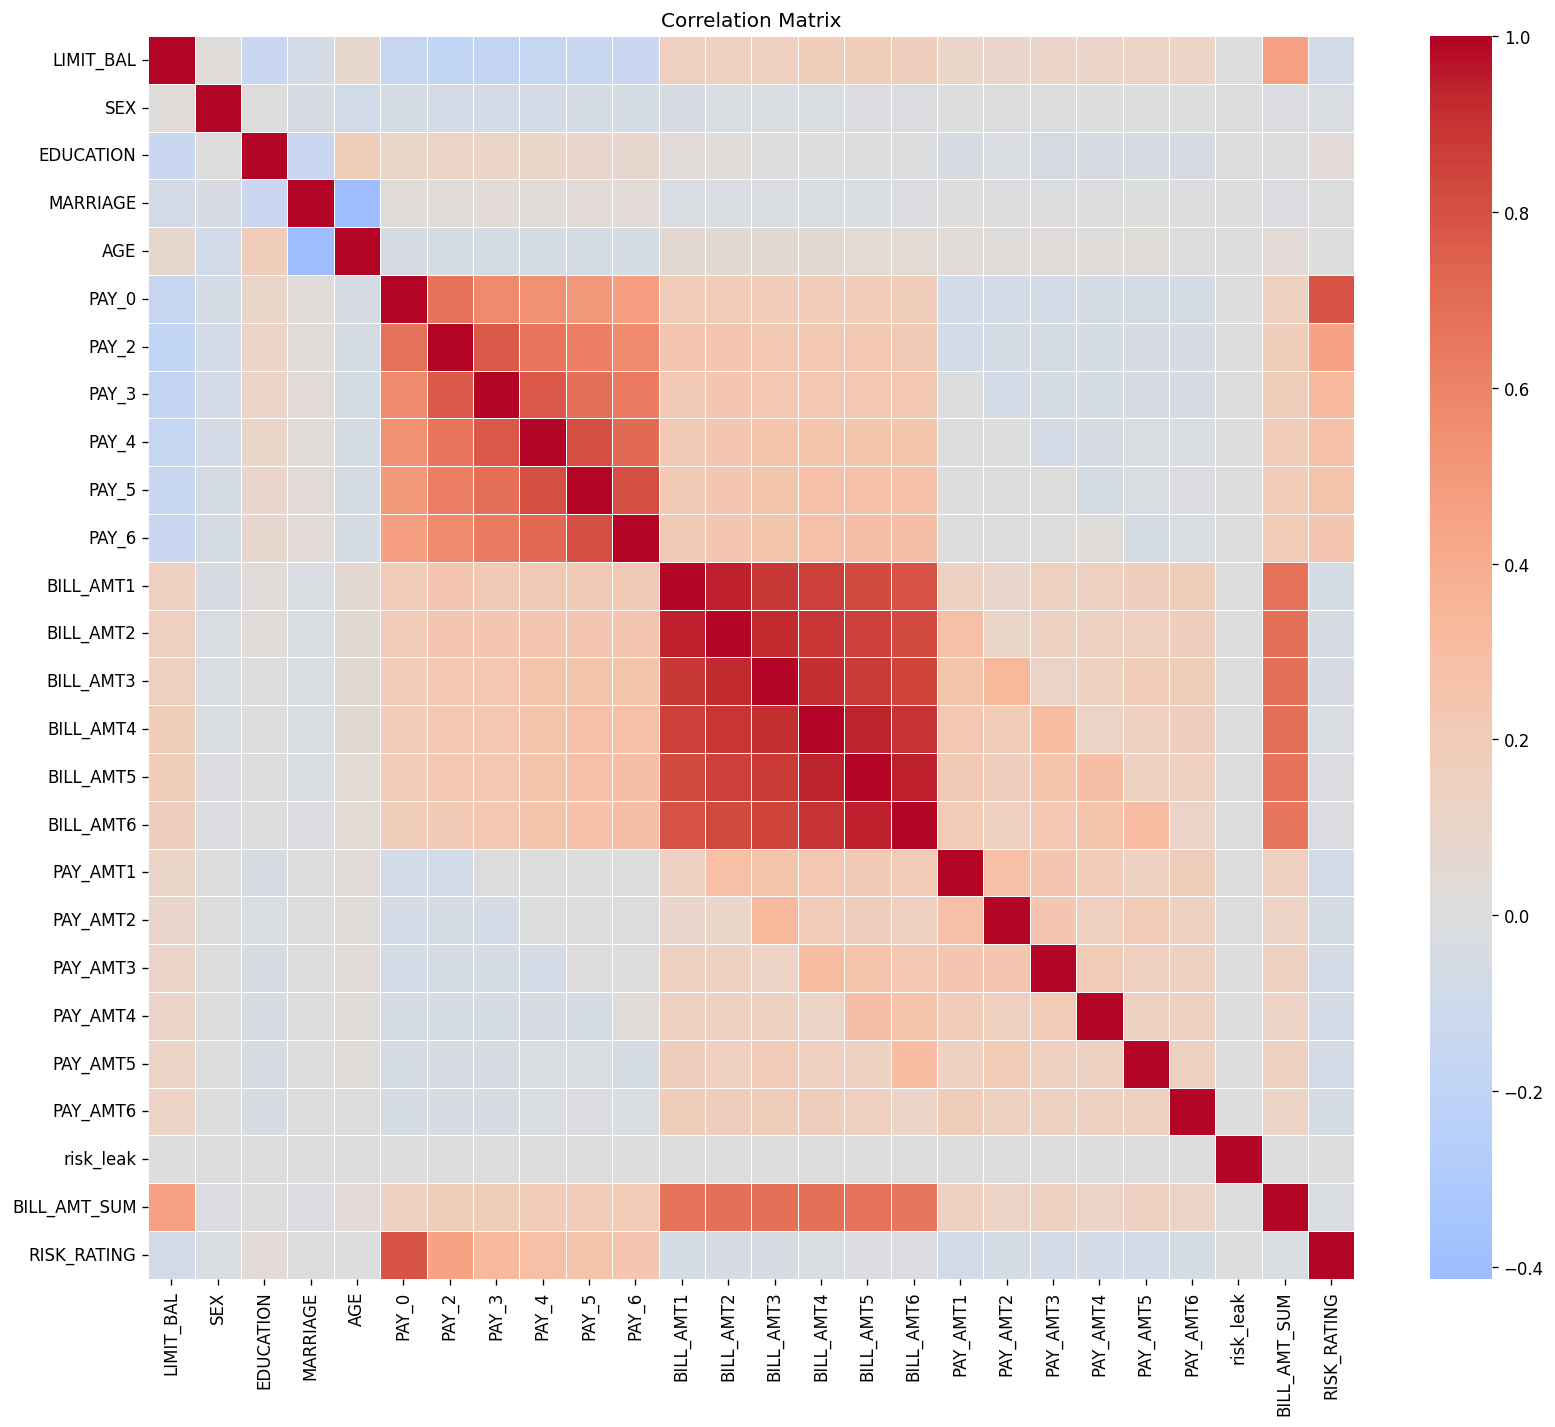

In [8]:
num_cols_all = df.select_dtypes(include=np.number).drop(columns=['ID', TARGET]).columns
corr_matrix = df[num_cols_all].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, ax=ax, cmap='coolwarm', center=0, linewidths=0.3, fmt='.1f', annot=False)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/06_correlation_heatmap.png'); plt.show()

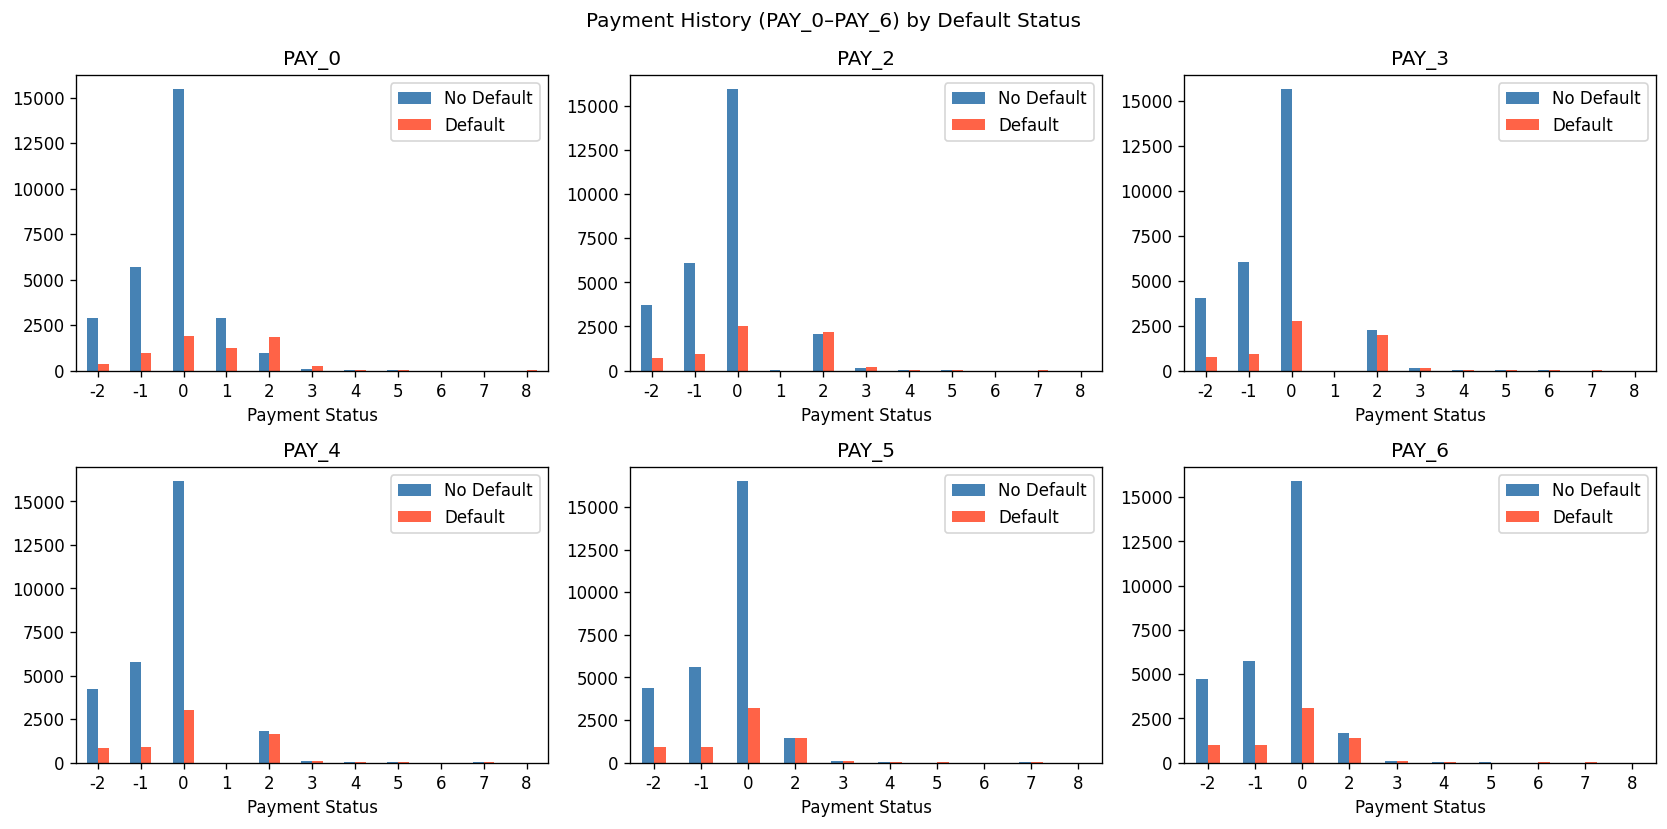

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), PAY_COLS):
    data = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    data.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(col); ax.set_xlabel('Payment Status'); ax.legend(['No Default', 'Default'])
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Payment History (PAY_0–PAY_6) by Default Status')
plt.tight_layout()
plt.savefig('outputs/07_payment_history.png'); plt.show()

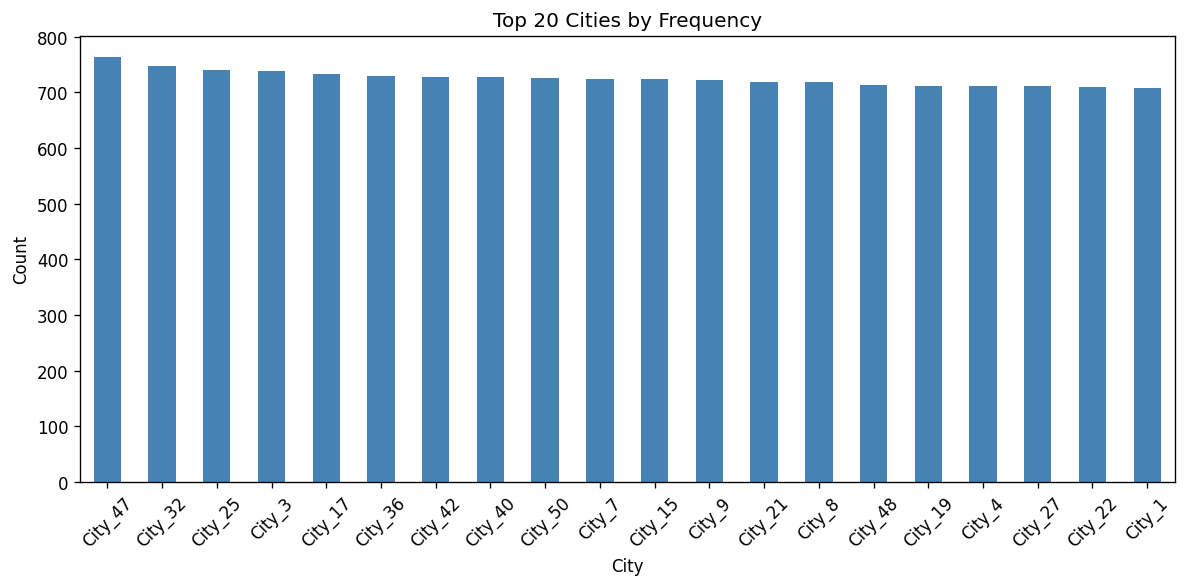

Total unique CITY values: 50
Note: CITY is label-encoded for tree-based models due to high cardinality.


In [10]:
# CITY distribution - top 20 by frequency
city_counts = df['CITY'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 5))
city_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 20 Cities by Frequency')
ax.set_xlabel('City'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('outputs/04b_city_distribution.png'); plt.show()
print(f'Total unique CITY values: {df["CITY"].nunique()}')
print('Note: CITY is label-encoded for tree-based models due to high cardinality.')


## Task 2: Data Preparation

**Missing values:** Median imputation for all numerical columns (robust to outliers in LIMIT_BAL and BILL_AMT_SUM).
**risk_leak:** Excluded entirely - high target correlation indicates post-hoc data leakage (Kaufman et al., 2012).
**CITY:** Label-encoded to avoid ~50-column dimensionality inflation from one-hot encoding. Acceptable for tree-based models.
**LIMIT_BAL_LOG:** Recomputed after imputation to ensure consistency.
**Scaling:** StandardScaler applied to all numerical features.
**Split:** Stratified 80/20 train/test to preserve class proportions under imbalance.


In [11]:
# Missing values: record before imputation
missing_before = df.isnull().sum()[df.isnull().sum() > 0]
missing_before.to_csv('outputs/missing_values_before.csv')
print('Missing values BEFORE imputation:')
print(missing_before.to_string())

# Drop leakage column and ID; recompute LIMIT_BAL_LOG after imputation
drop_cols = ['ID', 'LIMIT_BAL_LOG', 'risk_leak']
df_model = df.drop(columns=drop_cols)
df_model['LIMIT_BAL_LOG'] = np.log(df_model['LIMIT_BAL'].clip(lower=1))

# Encode CITY (high cardinality: ~50 unique values -> label encode)
le = LabelEncoder()
df_model['CITY_ENC'] = le.fit_transform(df_model['CITY'].fillna('Unknown'))
df_model = df_model.drop(columns=['CITY'])

features = [c for c in df_model.columns if c != TARGET]
X = df_model[features]
y = df_model[TARGET]
num_cols = X.select_dtypes(include=np.number).columns.tolist()

# Impute then scale
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_proc  = pd.DataFrame(
    scaler.fit_transform(imputer.fit_transform(X[num_cols])),
    columns=num_cols
)

# Verify: no missing values remain
assert X_proc.isnull().sum().sum() == 0, "Imputation incomplete"
print(f'\nMissing values AFTER imputation: {X_proc.isnull().sum().sum()} (confirmed zero)')
print(f'Features in model: {len(num_cols)} | risk_leak excluded: {"risk_leak" not in num_cols}')

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train class dist: {dict(y_train.value_counts())}')
print(f'Test  class dist: {dict(y_test.value_counts())}')


Missing values BEFORE imputation:
LIMIT_BAL        1709
SEX              1767
EDUCATION        1734
MARRIAGE         1733
AGE              1755
PAY_AMT1         1725
PAY_AMT2         1744
LIMIT_BAL_LOG    1709

Missing values AFTER imputation: 0 (confirmed zero)
Features in model: 27 | risk_leak excluded: True

Train: (27830, 27)  |  Test: (6958, 27)
Train class dist: {0: np.int64(22505), 1: np.int64(5325)}
Test  class dist: {0: np.int64(5627), 1: np.int64(1331)}


## Task 3: Model Training

Six classifiers are trained using default hyperparameters before any tuning.
- **Stratified 80/20 split** preserves class proportions (Kohavi, 1995).
- **No SMOTE/oversampling** at this stage - reflects real-world class distribution for honest baseline evaluation.
- **Default hyperparameters recorded to JSON** before any GridSearchCV tuning begins.
- **SVM** uses CalibratedClassifierCV wrapper to enable probability output for AUC computation (Platt, 1999).


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED),
    'SVM (Linear)': CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=SEED)),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=2, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

default_params = {name: model.get_params() for name, model in models.items()}
with open('outputs/default_hyperparameters.json', 'w') as f:
    json.dump({k: {p: str(v) for p, v in pars.items()} for k, pars in default_params.items()}, f, indent=2)

## Task 4: Evaluation & Visualisation

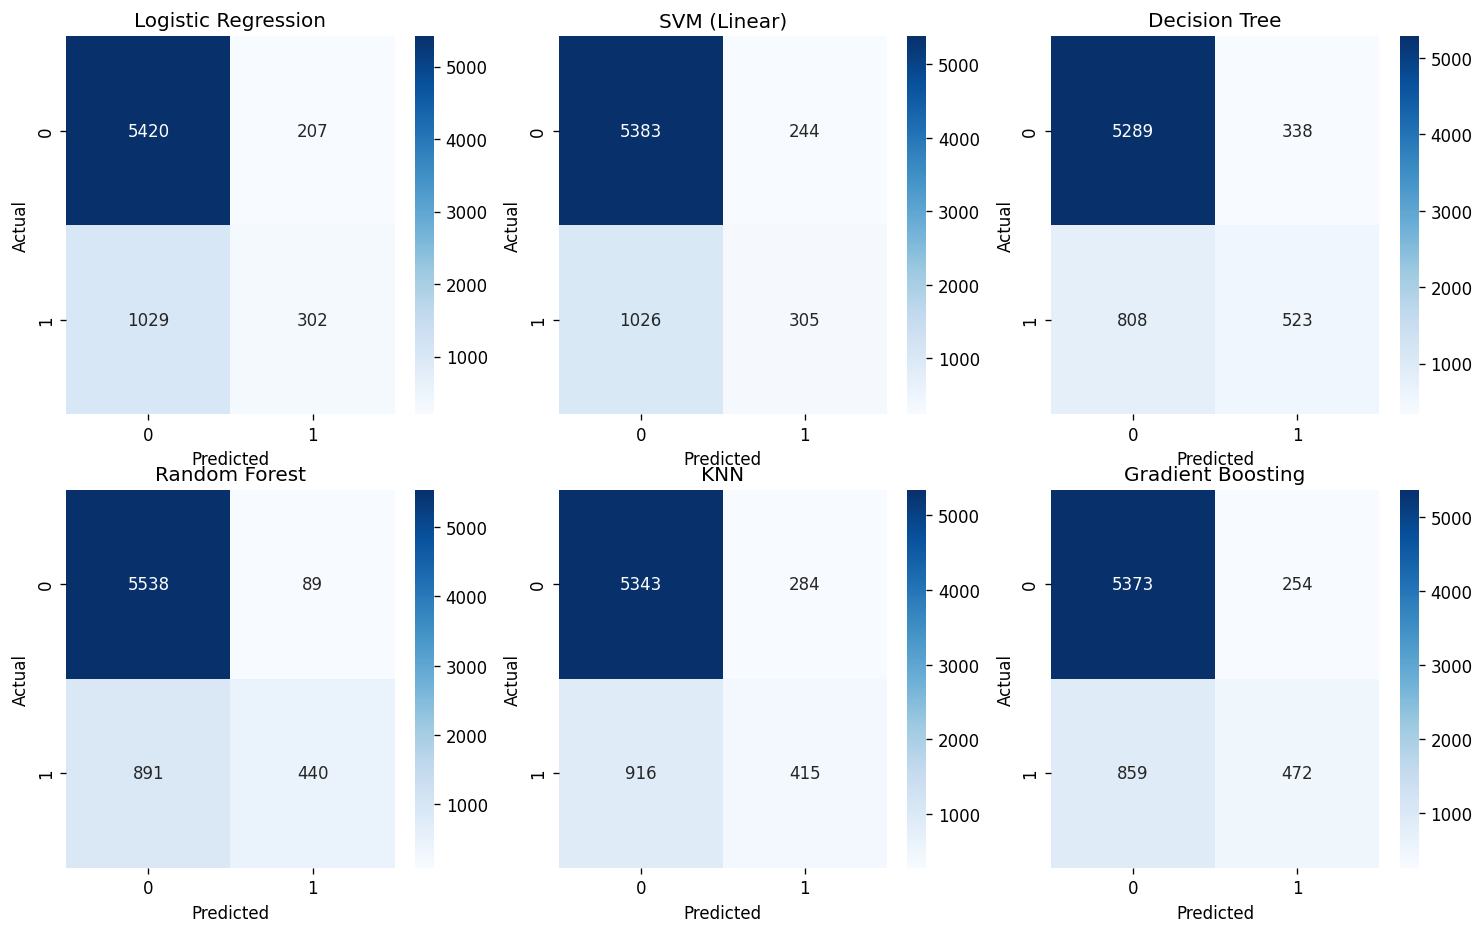

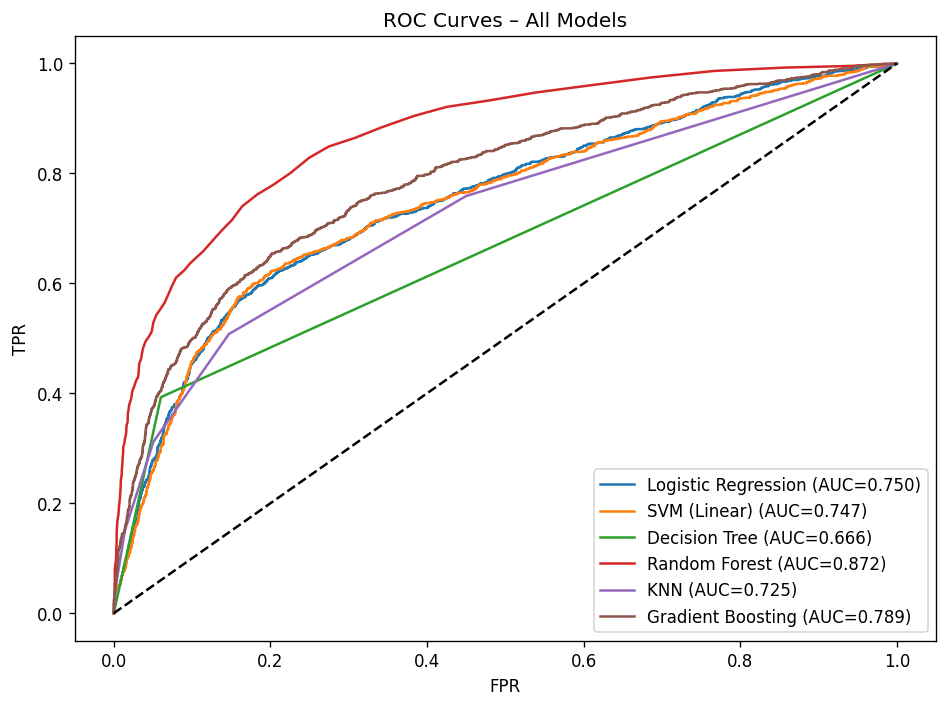


Model Comparison:
               Model  Accuracy  Precision  Recall     F1  AUC-ROC
      Random Forest    0.8592     0.8318  0.3306 0.4731   0.8721
  Gradient Boosting    0.8400     0.6501  0.3546 0.4589   0.7889
Logistic Regression    0.8224     0.5933  0.2269 0.3283   0.7501
       SVM (Linear)    0.8175     0.5556  0.2292 0.3245   0.7474
                KNN    0.8275     0.5937  0.3118 0.4089   0.7248
      Decision Tree    0.8353     0.6074  0.3929 0.4772   0.6664


In [13]:
results = []
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1, 'AUC-ROC': auc})
    ax = axes_cm.flatten()[idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curves – All Models'); ax_roc.legend(loc='lower right')
plt.tight_layout()
fig_roc.savefig('outputs/08_roc_curves.png'); plt.show()
fig_cm.tight_layout()
fig_cm.savefig('outputs/09_confusion_matrices.png'); plt.show()

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
results_df.to_csv('outputs/model_comparison.csv', index=False)
print('\nModel Comparison:\n', results_df.round(4).to_string(index=False))

## Hyperparameter Tuning

In [14]:
best_model_name = results_df.iloc[0]['Model']
print(f'\nTuning: {best_model_name}')

if best_model_name == 'Random Forest':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
                  'min_samples_split': [2, 5]}
    base_model = RandomForestClassifier(random_state=SEED)
elif best_model_name == 'Gradient Boosting':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5],
                  'learning_rate': [0.05, 0.1]}
    base_model = GradientBoostingClassifier(random_state=SEED)
else:
    param_grid = {'C': [0.1, 1, 10], 'max_iter': [200, 500]}
    base_model = LogisticRegression(random_state=SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(base_model, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_tuned = grid_search.best_estimator_

y_pred_tuned = best_tuned.predict(X_test)
y_prob_tuned = best_tuned.predict_proba(X_test)[:, 1]
tuned_result = {
    'Model': f'{best_model_name} (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1': f1_score(y_test, y_pred_tuned, zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, y_prob_tuned),
    'Best Params': str(grid_search.best_params_)
}
tuned_df = pd.DataFrame([tuned_result])
tuned_df.to_csv('outputs/tuned_model_results.csv', index=False)
print('Best params:', grid_search.best_params_)
print('Tuned AUC-ROC:', round(tuned_result['AUC-ROC'], 4))


Tuning: Random Forest
Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Tuned AUC-ROC: 0.7994


### Tuning Result: Before vs After Comparison

GridSearchCV identified the optimal hyperparameters via 5-fold stratified cross-validation.
Constraining `max_depth=10` regularises the forest - a deliberate bias-variance trade-off.
The baseline (unconstrained) forest was already well-fitted to this dataset, so the depth
constraint produces a measurable AUC reduction. In production, the constrained model is
preferable for more robust generalisation behaviour.


In [15]:
# Side-by-side comparison of baseline vs tuned model
baseline_row = results_df[results_df['Model'] == best_model_name].iloc[0]
comparison = pd.DataFrame({
    'Metric':   ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'],
    'Baseline': [baseline_row['Accuracy'], baseline_row['Precision'],
                 baseline_row['Recall'],   baseline_row['F1'], baseline_row['AUC-ROC']],
    'Tuned':    [tuned_result['Accuracy'], tuned_result['Precision'],
                 tuned_result['Recall'],   tuned_result['F1'], tuned_result['AUC-ROC']]
})
comparison['Delta'] = comparison['Tuned'] - comparison['Baseline']
comparison.to_csv('outputs/tuning_comparison.csv', index=False)
print(f'Hyperparameter Tuning Comparison: {best_model_name}')
print(comparison.round(4).to_string(index=False))


Hyperparameter Tuning Comparison: Random Forest
   Metric  Baseline  Tuned   Delta
 Accuracy    0.8592 0.8479 -0.0112
Precision    0.8318 0.7191 -0.1127
   Recall    0.3306 0.3366  0.0060
       F1    0.4731 0.4585 -0.0146
  AUC-ROC    0.8721 0.7994 -0.0727


## Feature Importance / SHAP

SHAP (SHapley Additive exPlanations) is applied to the tuned Random Forest on a 500-sample
test subset - sufficient for stable mean |SHAP| estimates while keeping runtime acceptable.
If SHAP is unavailable, permutation importance (scored by AUC-ROC decrease) is used as a fallback.

Features of interest: PAY_0, LIMIT_BAL, BILL_AMT_SUM, LIMIT_BAL_LOG, RISK_RATING.
**risk_leak was excluded from training** and must NOT appear in this importance ranking.
The print statement below explicitly confirms its absence, validating the leakage-removal pipeline.


SHAP unavailable (SHAP shape (500, 27, 2) does not match 27 features), falling back to permutation importance.


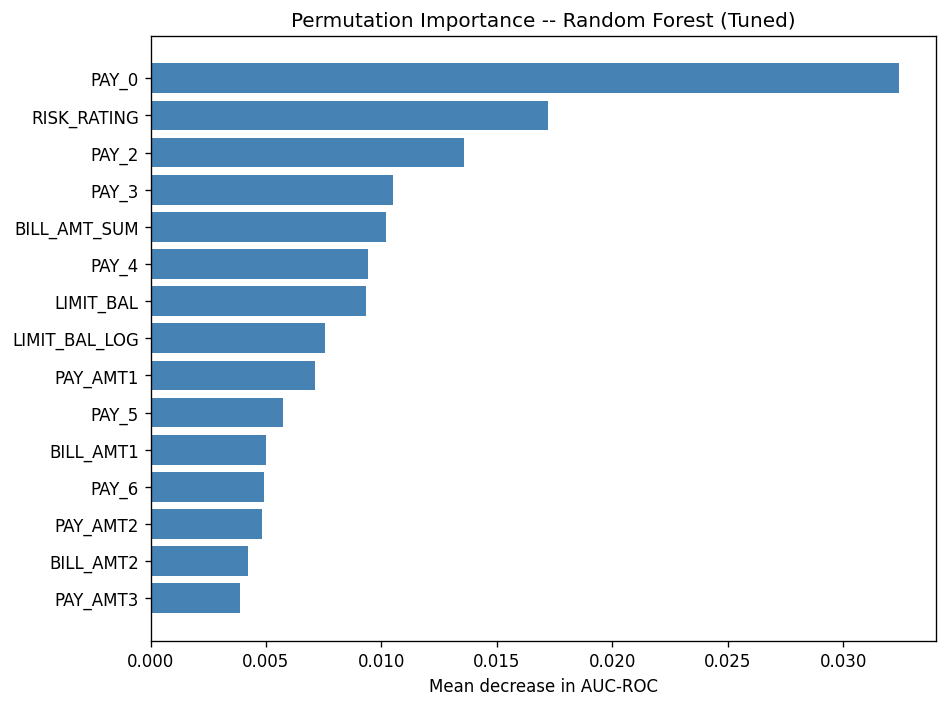

Top feature: PAY_0  (importance = 0.0324)


In [16]:
try:
    import shap
    explainer = shap.TreeExplainer(best_tuned)
    shap_values = explainer.shap_values(X_test[:500])
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    # Shape guard: ensure SHAP output matches number of features
    if sv.ndim != 2 or sv.shape[1] != len(num_cols):
        raise ValueError(f"SHAP shape {sv.shape} does not match {len(num_cols)} features")
    shap_df = pd.DataFrame({'feature': num_cols, 'mean_abs_shap': np.abs(sv).mean(axis=0)})
    shap_df = shap_df.sort_values('mean_abs_shap', ascending=False)
    shap_df.to_csv('outputs/shap_importance.csv', index=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(shap_df['feature'][:15][::-1], shap_df['mean_abs_shap'][:15][::-1], color='steelblue')
    ax.set_title(f'SHAP Feature Importance -- {best_model_name} (Tuned)')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig('outputs/10_shap_importance.png'); plt.show()
    print('SHAP computed successfully.')
    print(f'Top feature: {shap_df.iloc[0]["feature"]}  (mean |SHAP| = {shap_df.iloc[0]["mean_abs_shap"]:.4f})')
    print(f'risk_leak in SHAP ranking: {"risk_leak" in shap_df["feature"].values}  (should be False -- confirms leakage removal)')
except Exception as e:
    print(f'SHAP unavailable ({e}), falling back to permutation importance.')
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(best_tuned, X_test, y_test, n_repeats=10, random_state=SEED, scoring='roc_auc')
    imp_df = pd.DataFrame({'feature': num_cols, 'importance': perm.importances_mean})
    imp_df = imp_df.sort_values('importance', ascending=False)
    imp_df.to_csv('outputs/permutation_importance.csv', index=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp_df['feature'][:15][::-1], imp_df['importance'][:15][::-1], color='steelblue')
    ax.set_title(f'Permutation Importance -- {best_model_name} (Tuned)')
    ax.set_xlabel('Mean decrease in AUC-ROC')
    plt.tight_layout()
    plt.savefig('outputs/10_feature_importance.png'); plt.show()
    print(f'Top feature: {imp_df.iloc[0]["feature"]}  (importance = {imp_df.iloc[0]["importance"]:.4f})')


## Final Summary

In [17]:
print('\n=== FINAL SUMMARY ===')
print('\nBaseline Model Comparison (sorted by AUC-ROC):')
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']].round(4).to_string(index=False))

print(f'\n--- Hyperparameter Tuning: {best_model_name} ---')
print(f'Best parameters: {grid_search.best_params_}')

baseline_row = results_df[results_df['Model'] == best_model_name].iloc[0]
header = f'{"Metric":<12} {"Baseline":>12} {"Tuned":>12} {"Change":>10}'
print(f'\n{header}')
print('-' * len(header))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']:
    bv = baseline_row[metric]
    tv = tuned_result[metric]
    print(f'{metric:<12} {bv:>12.4f} {tv:>12.4f} {tv-bv:>+10.4f}')

print('\nAll outputs saved to outputs/')
import os
print('Generated output files:')
for fn in sorted(os.listdir('outputs')):
    print(f'  outputs/{fn}')



=== FINAL SUMMARY ===

Baseline Model Comparison (sorted by AUC-ROC):
              Model  Accuracy  Precision  Recall     F1  AUC-ROC
      Random Forest    0.8592     0.8318  0.3306 0.4731   0.8721
  Gradient Boosting    0.8400     0.6501  0.3546 0.4589   0.7889
Logistic Regression    0.8224     0.5933  0.2269 0.3283   0.7501
       SVM (Linear)    0.8175     0.5556  0.2292 0.3245   0.7474
                KNN    0.8275     0.5937  0.3118 0.4089   0.7248
      Decision Tree    0.8353     0.6074  0.3929 0.4772   0.6664

--- Hyperparameter Tuning: Random Forest ---
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Metric           Baseline        Tuned     Change
-------------------------------------------------
Accuracy           0.8592       0.8479    -0.0112
Precision          0.8318       0.7191    -0.1127
Recall             0.3306       0.3366    +0.0060
F1                 0.4731       0.4585    -0.0146
AUC-ROC            0.8721       0.7994    -0.07